# 📌 Objective

### This notebook is to understand the Indian housing dataset to identify:
* Data quality issues
*  Price distribution patterns
*  Relationship between property area and price
*  relationship between house area and price

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

### Load the Dataset

In [12]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\data\House Price India.csv")

### Dataset Overview

**Shape of the dataset**

In [13]:
df.shape

(14619, 23)

**Column Names & Data Types**

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

**Preview Sample Records**

In [15]:
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


**Missing Values Analysis**

In [16]:
df.isnull().sum().sort_values(ascending=False)

id                                       0
Area of the basement                     0
Distance from the airport                0
Number of schools nearby                 0
lot_area_renov                           0
living_area_renov                        0
Longitude                                0
Lattitude                                0
Postal Code                              0
Renovation Year                          0
Built Year                               0
Area of the house(excluding basement)    0
Date                                     0
grade of the house                       0
condition of the house                   0
number of views                          0
waterfront present                       0
number of floors                         0
lot area                                 0
living area                              0
number of bathrooms                      0
number of bedrooms                       0
Price                                    0
dtype: int6

**Descriptive Statistics**

In [17]:
df.describe()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,...,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04
mean,6.762821e+09,42604.546412,3.379233,2.129557,2098.156851,1.509369e+04,1.502326,0.007661,0.232848,3.430399,...,1970.929817,90.930228,122033.064300,52.792843,-114.403996,1996.641836,12754.003078,2.012244,64.951433,5.388063e+05
std,6.237162e+03,67.343747,0.938655,0.769955,928.218740,3.792089e+04,0.540241,0.087196,0.765651,0.664047,...,29.491743,416.230218,19.081451,0.137525,0.141325,691.078387,26059.234785,0.817312,8.936129,3.672294e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5.010500e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.500000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


### Distribution of House Prices - Histogram

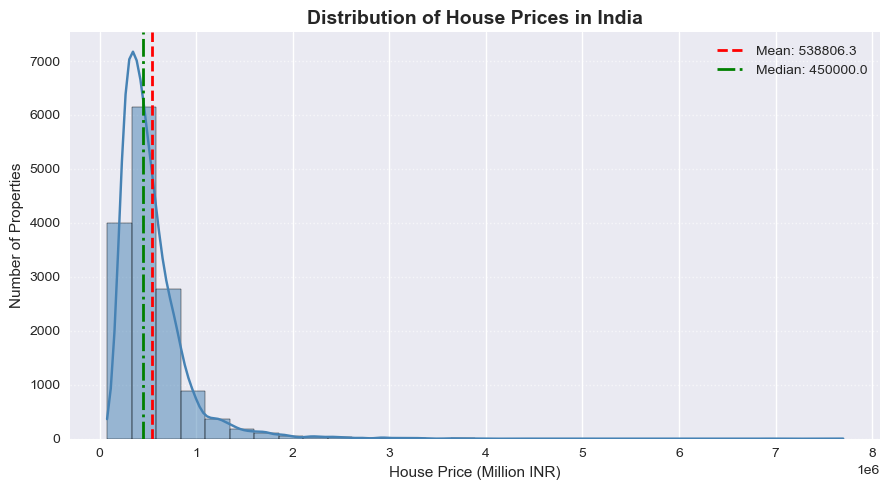

In [19]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["Price"],
    bins=30,
    kde=True,
    color="steelblue",
    edgecolor="black"
)

# Central tendency
mean_price = df["Price"].mean()
median_price = df["Price"].median()

plt.axvline(mean_price, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_price:.1f}")
plt.axvline(median_price, color="green", linestyle="-.", linewidth=2, label=f"Median: {median_price:.1f}")

# Labels & title
plt.title("Distribution of House Prices in India", fontsize=14, fontweight="bold")
plt.xlabel("House Price (Million INR)")
plt.ylabel("Number of Properties")

plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Relationship analysis - Scatter plot (Area vs Price)

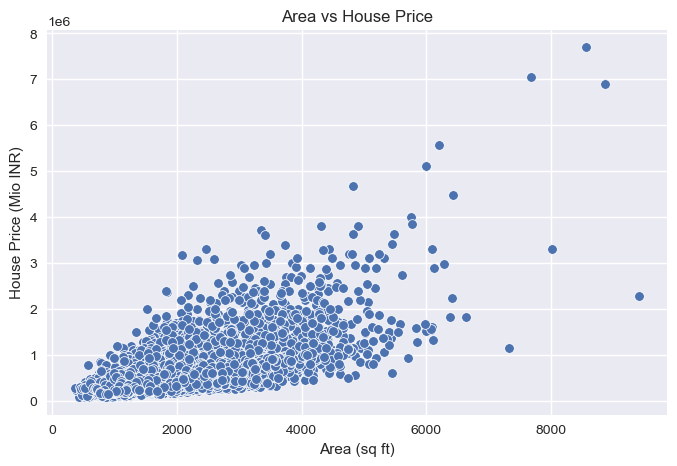

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Area of the house(excluding basement)"], y=df["Price"])
plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("House Price (Mio INR)")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\area_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Correlation analysis - Correlation Heatmap

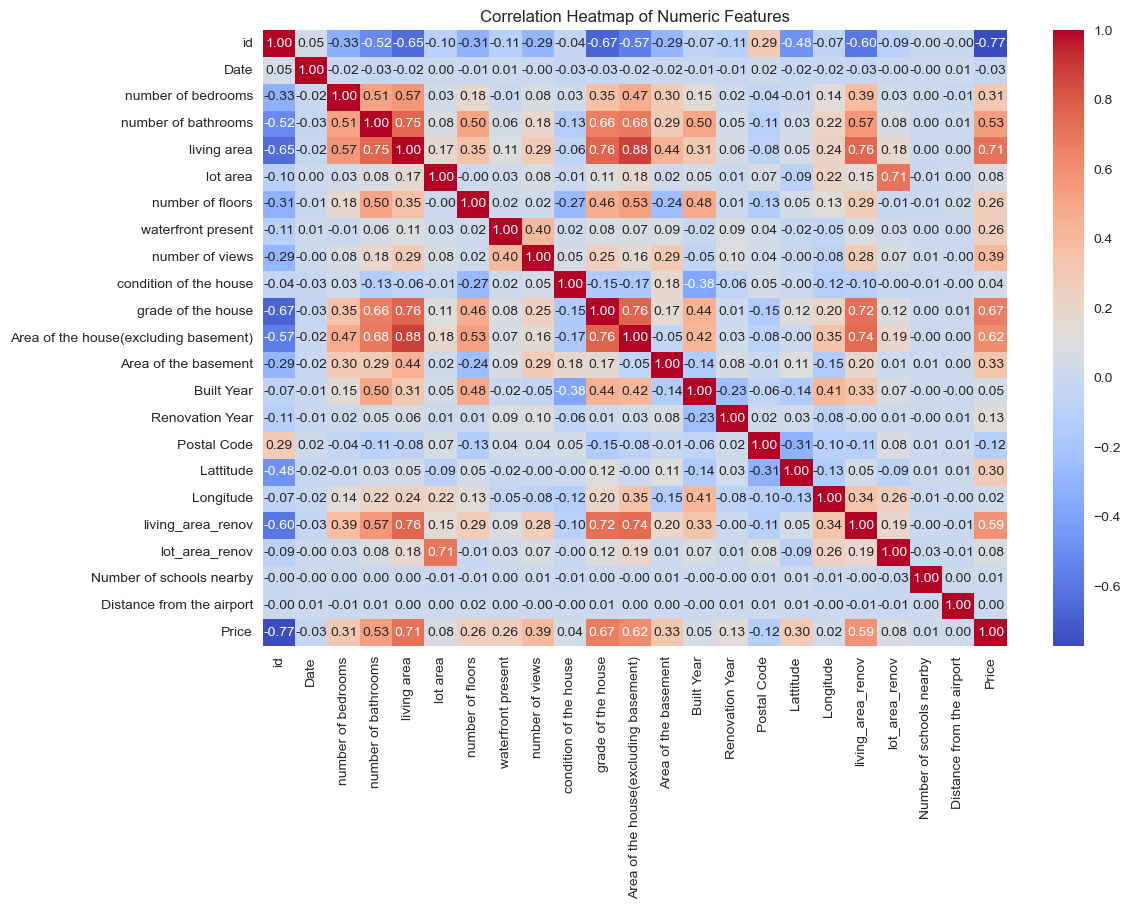

In [21]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Exploratory Data Analysis – Key Observations

1. **Area vs Price Relationship**  
   The scatter plot shows a clear positive linear relationship between house area and price. Larger houses generally have higher market prices, making area a strong predictor for modeling.

2. **Distribution of House Prices**  
   House prices are slightly right-skewed, indicating the presence of a few high-value properties. This is common in real estate datasets where luxury homes influence the upper range.

3. **Area Distribution**  
   Most houses fall within a mid-range area size, with fewer extremely small or extremely large properties. These extreme values were examined and treated during outlier handling.

4. **Correlation Analysis**  
   The correlation heatmap confirms that house area has one of the strongest positive correlations with price among the available numerical features. This supports selecting area as the primary feature for linear regression.

5. **Outlier Impact**  
   Some unusually large properties and very high-priced homes were detected. These outliers were capped using the IQR method to prevent distortion of the regression model.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Outlier treatment - Boxplot (Area vs Price)

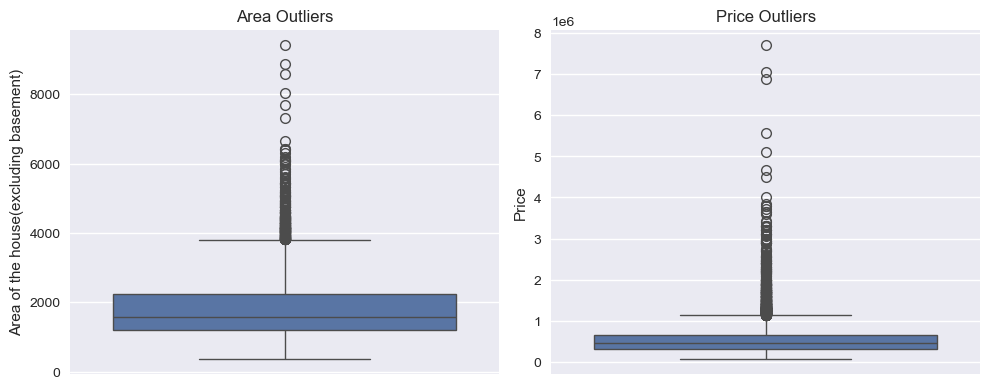

In [23]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(y=df["Area of the house(excluding basement)"])
plt.title("Area Outliers")

plt.subplot(1,2,2)
sns.boxplot(y=df["Price"])
plt.title("Price Outliers")

plt.tight_layout()
plt.show()

### Capping outliers

In [24]:
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

cap_outliers("Area of the house(excluding basement)")
cap_outliers("Price")

### Feature selection

In [25]:
X = df[["Area of the house(excluding basement)"]]
y = df["Price"]

### Train-Test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train.shape, X_test.shape

((10233, 1), (4386, 1))

### Feature scaling

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Train Linear Regression Model

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Model Parameters Interpretation

In [30]:
model.coef_, model.intercept_

(array([197.11677043]), 159952.80134430726)

### Predictions

In [31]:
y_pred = model.predict(X_test)

### Model evaluation

In [32]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(154230.12669909917, 195258.31612008356, 0.39320338333946003)

### Actual vs Predicted Visualization

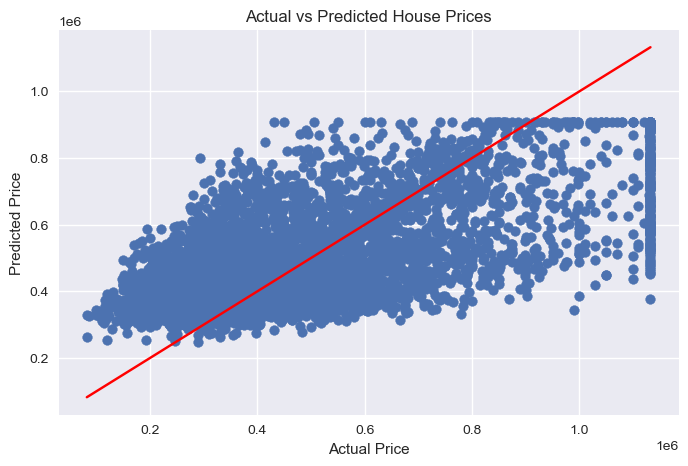

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\actual_vs_predicted_prices.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Predict Price for New Input

In [34]:
new_area = pd.DataFrame({"Area of the house(excluding basement)": [1500]})
predicted_price = model.predict(new_area)
predicted_price

array([455627.9569962])

In [36]:
import os
import joblib

os.makedirs("models", exist_ok=True)
joblib.dump(model, r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\house_price_app\house_price_model.pkl")

['C:\\Users\\Admin\\OneDrive\\Desktop\\Sitaram_Github\\AI_ML_projects\\01_linear_regression_house_price\\house_price_app\\house_price_model.pkl']

### Residual calculation

In [37]:
residuals = y_test - y_pred

### Residual distribution - Histogram of Residuals

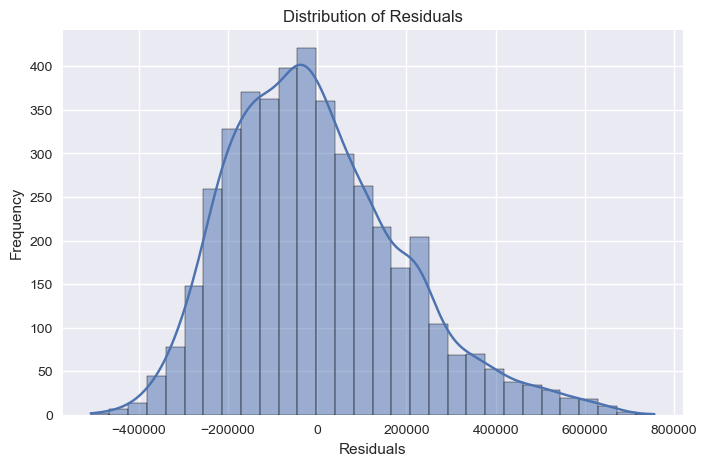

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Residuals vs Predicted Values - Scatter plot

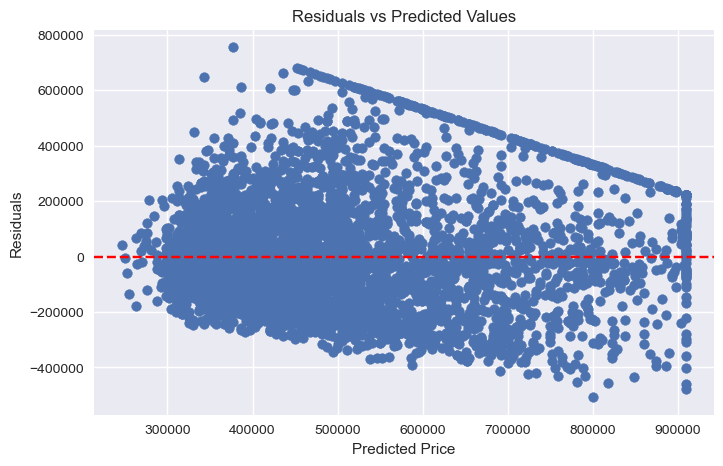

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

### Error metrics summary

In [40]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Value": [mae, rmse, r2]
})

,Metric,Value
0,MAE,154230.126699
1,RMSE,195258.316120
2,R² Score,0.393203


### Model Insights and Interpretation

1. **Feature Importance**  
   House area was used as the predictor variable, and the model confirms it has a strong influence on price. As the area increases, the predicted house price also increases.

2. **Coefficient Interpretation**  
   The linear regression coefficient indicates the expected increase in house price for every one unit increase in area. This provides a clear and interpretable business relationship between property size and value.

3. **Model Performance**  
   Evaluation metrics such as MAE, MSE, and R² score suggest the model captures a significant portion of the variation in house prices using area alone. While simple, the model provides a reasonable baseline for price estimation.

4. **Residual Analysis**  
   Residual plots show that errors are distributed around zero without a strong visible pattern. This suggests that the linear regression assumptions are reasonably satisfied for this dataset.

5. **Business Insight**  
   The model demonstrates that property size is a primary driver of house prices. This insight can help real estate stakeholders estimate property value, compare listings, and support pricing decisions.